# Banknote classification with fcNN without hidden layer compared to fcNN with hidden layer


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tensorchiefs/dl_course_2025/blob/master/notebooks/02_fcnn_with_banknote_keras_torch.ipynb)

In this notebook you will do your first classification. You will see that fully connected networks without a hidden layer can only learn linar decision boundaries, while fully connected networks with hidden layers are able to learn non-linear decision boundaries.

**Dataset:** You work with a banknote data set and classification task. We have 5 features of wavelet transformed images of banknotes:
>1. variance  (continuous feature)
>2. skewness (continuous feature)
>3. curtosis (continuous feature)
>4. entropy (continuous feature)
>5. class (binary indicating if the banknote is real or fake)  

Don't worry too much about where these features come from.

For this analysis we only use 2 features.

>x1: skewness of wavelet transformed image  
>x2: entropy of wavelet transformed image


**The goal is to classify each banknote to either "real" (Y=0) or "fake" (Y=1).**


**Content:**
* visualize the data in a simple scatter plot and color the points by the class label
* use the Keras library to build a fcNN without hidden layers (logistic regression). Use SGD with the objective to minimize the crossentropy loss.
* visualize the learned decision boundary in a 2D plot
* use the Keras library to build a fcNN with a single hidden layer. Use SGD with the objective to minimize the crossentropy loss.
* visualize the learned decision boundary in a 2D plot
* compare the performace and the decision boundaries of the two models
* stack more hidden layers to the model and playaround with the epochs






## Imports and auxiliary functions

In the next two cells, we load all the required libraries and functions from keras and numpy. We also download the data with the 5 features from the provided url.

In [24]:
# load required libraries:
import numpy as np
import matplotlib.pyplot as plt
import time
%matplotlib inline
plt.style.use('default')

import os
# os.environ["KERAS_BACKEND"] = "torch"
os.environ["KERAS_BACKEND"] = "jax"
import keras

backend_name = keras.backend.backend()
print(f"Keras backend: {backend_name}.")
if backend_name == "jax":
    import jax
    print(f"Backend version (JAX): {jax.__version__}")
elif backend_name == "tensorflow":
    import tensorflow
    print(f"Backend version (TensorFlow): {tensorflow.__version__}")
elif backend_name == "torch":
    import torch
    print(f"Backend version (PyTorch): {torch.__version__}")
else:
    print(f"Unknown backend: {backend_name}")

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD

Keras backend: jax.
Backend version (JAX): 0.7.2


In [25]:
backend_name = keras.backend.backend()
print(f"Keras is using the {backend_name} backend.")

if backend_name == "jax":
    import jax
    print(f"Backend version (JAX): {jax.__version__}")
elif backend_name == "tensorflow":
    import tensorflow
    print(f"Backend version (TensorFlow): {tensorflow.__version__}")
elif backend_name == "torch":
    import torch
    print(f"Backend version (PyTorch): {torch.__version__}")
else:
    print(f"Unknown backend: {backend_name}")

Keras is using the jax backend.
Backend version (JAX): 0.7.2


In [26]:
# 🔧 Define a helper function to plot learning curves
def plot_learning_curves(history):
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    ax = axs[0]
    ax.plot(history.history['loss'], label="training")
    if history.history.get('val_loss') is not None:
        ax.plot(history.history['val_loss'], label="validation")
    ax.set_title('model loss')
    ax.set_ylabel('loss')
    ax.set_xlabel('epoch')
    ax.legend()
    ax.grid()

    ax = axs[1]
    ax.plot(history.history['accuracy'], label="training")
    if history.history.get('val_accuracy') is not None:
        ax.plot(history.history['val_accuracy'], label="validation")
    ax.set_title('model accuracy')
    ax.set_ylabel('accuracy')
    ax.set_xlabel('epoch')
    ax.legend()
    ax.grid()

    return fig

In [27]:
def plotModel(X,Y, model, t):
    # define a grid for the 2D feature space
    n_res = 51
    x1list = np.linspace(np.min(X[:,0])-2, np.max(X[:,0])+2, n_res) # Define 100 points on the x-axis
    x2list = np.linspace(np.min(X[:,1])-2, np.max(X[:,1])+2, n_res) # Define 100 points on the x-axis
    X1_grid, X2_grid = np.meshgrid(x1list, x2list)

    X_grid = np.r_[
        X1_grid.reshape(1, n_res*n_res),
        X2_grid.reshape(1, n_res*n_res)
    ].T

    # predict at each grid point the probability for class 1
    p = model.predict(X_grid)
    if p.shape[1]==2:
        p = p[:,1] # pick p for class 1 if there are more than 2 classes
    # Reshape the predicted probabilities to a shape that can be used for contouring
    # by `pyplot`
    p = np.reshape(p,X1_grid.shape)

    # Visualize the predicted probabilities in the 2D feature space
    # with the data points used for fitting
    fig, ax = plt.subplots(figsize=(9,5))
    cp = ax.contourf(X1_grid, X2_grid, p,cmap='RdBu_r', levels=30)
    plt.colorbar(cp)
    idx_f = [np.where(Y==1)]
    idx_r = [np.where(Y==0)]
    ax.scatter(X[idx_r,0],X[idx_r,1], alpha=0.7,marker='o', s=3, edgecolors=None)
    ax.scatter(X[idx_f,0],X[idx_f,1], alpha=0.7,marker='o', s=3, edgecolors=None)
    ax.set_title(t)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

In [28]:
# 🔧 Helper function to reset model weights
def reset_weights(model):
    for layer in model.layers:
        # Check if the layer has initializers (weights and biases)
        if hasattr(layer, 'kernel_initializer') and hasattr(layer, 'bias_initializer'):
            # Generate new weights using the layer's original initializer
            new_weights = layer.kernel_initializer(layer.kernel.shape)
            new_biases = layer.bias_initializer(layer.bias.shape)

            # Update the layer weights
            layer.set_weights([new_weights, new_biases])


## Load data

In [29]:
# Load data from url
from urllib.request import urlopen
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt'
raw_data = urlopen(url)
dataset = np.loadtxt(raw_data, delimiter=",")
print(dataset.shape)

(1372, 5)


Let's extract the two featues *x1: skewness of wavelet transformed image* and *x2: entropy of wavelet transformed image*. We print the shape and see that for X  we have 1372 oberservations with two features and for Y there are 1372 binary labels.

In [30]:
# Here we extract the two features and the labels of the dataset
X=dataset[:,[1,3]]
Y=dataset[:,4]
print(X.shape)
print(Y.shape)

(1372, 2)
(1372,)


Since the banknotes are described by only 2 features, we can easily visualize the positions of real and fake banknotes in a 2D feature space. You can see that the boundary between the two classes is not separable by a straight line. A curved boundary line will do better. But even then we cannot expect a perfect seperation.


**Note**: The target value of `y[i]` being `0` indicates a real bank note, a value of `1` indicates a fake bank note.

number of fakes: 610
number of reals: 762


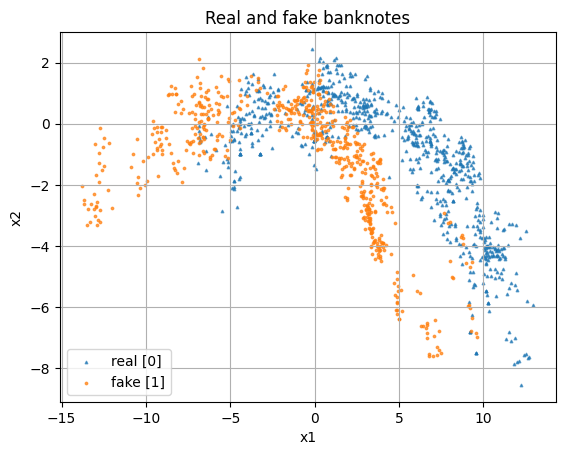

In [31]:
# visualize the data in a 2D feature space.
idx_f = [np.where(Y==1)]
idx_r = [np.where(Y==0)]

print(f'number of fakes: {idx_f[0][0].shape[0]}')
print(f'number of reals: {idx_r[0][0].shape[0]}')

plt.scatter(X[idx_r,0],X[idx_r,1], alpha=0.7,marker='^', s=3)
plt.scatter(X[idx_f,0],X[idx_f,1], alpha=0.7,marker='o', s=3)
plt.title("Real and fake banknotes")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(("real [0]", "fake [1]"),
           loc='lower left',
           fontsize=10)
plt.grid()

## fcNN with only one neuron
Let’s try to use a single neuron with a sigmoid activation function (also known as logistic regression) as classification model to seperate the banknotes.  
We use the sequential API from keras to build the model. To fit the 3 parameters we use the stochastic gradient descent optimizer with a learning rate of 0.15.

### Definition of a NN with only one neuron after the input


We build a logistic regression model in Keras.
This is done through the definition of a single-neuron network.

Below we follow the so called functional style of defining the network


In [32]:
# Set the random seed for reproducibility
keras.utils.set_random_seed(42)

# Our network starts with two inputs
inputs = keras.Input(shape=(2,))
# Those inputs are then fed into a single-neuron layer, with activation "sigmoid"
# This is already our final layer and its output is thus the network output
output = Dense(1, activation="sigmoid")(inputs)

# Create the model
model_neuron = keras.Model(inputs, output)

In [ ]:
# For reference: Here's the sequential style of defining a neural network
# This style is more limited in what types of network architectures it allows.
model_alt = Sequential()
model_alt.add(Dense(1, input_shape=(2,), activation='sigmoid'))


In [36]:
# We now define an optimizer. This here is "stochastic gradient descent"
# and we've come across it in notebook 01*.
sgd = SGD(learning_rate=0.15)

# Now that we have the model defined and an optimizer set up, we can
# go through the compile step.
# In compilation, we define the loss function, the optimizer as well as
# some metrics that we want to track. That metric here is the accuracy.
model_neuron.compile(loss='binary_crossentropy',
              optimizer=sgd,
              metrics=['accuracy'])

# This ends the definition of the model

In [37]:
# summarize the architecture of the NN along with the number of weights
model_neuron.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In the next cell, we train the network. In other words, we take the parameters that were initialized randomly and tune them with stochastic gradient descent in such a way as to minimize our loss function. Note that that loss function is the binary crossentropy. We set the batchsize to 128 per update step and train for 80 epochs. That means that the optimization, that tuning of the parameters, will recycle through all our data point 80 times.

In [38]:
X.shape

(1372, 2)

In [39]:
# Training of the network
history = model_neuron.fit(X, Y,                           # training of the model using the training data stored in X and Y for 4100 epochs
          epochs=80,                               # for 400 epochs
          batch_size=128,                           # fix the batch size to 128 examples
          verbose=1)


Epoch 1/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6749 - loss: 0.8169
Epoch 2/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7325 - loss: 0.5185
Epoch 3/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7340 - loss: 0.5172
Epoch 4/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7325 - loss: 0.5153
Epoch 5/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7230 - loss: 0.5137
Epoch 6/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7187 - loss: 0.5131
Epoch 7/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7194 - loss: 0.5145
Epoch 8/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7157 - loss: 0.5154
Epoch 9/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7157 - loss: 0.5130
Epoch 10/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7165 - loss: 0.5127
Epoch 11/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7128 - loss: 0.5128
Epoch 12/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7165 - l

To look at the so called leraning curve, we plot the accuracy and the loss vs the epochs. You can see that after 80 epochs, we predict around 71% of our data correct and have a loss of around 0.51 (these values can vary from run to run).

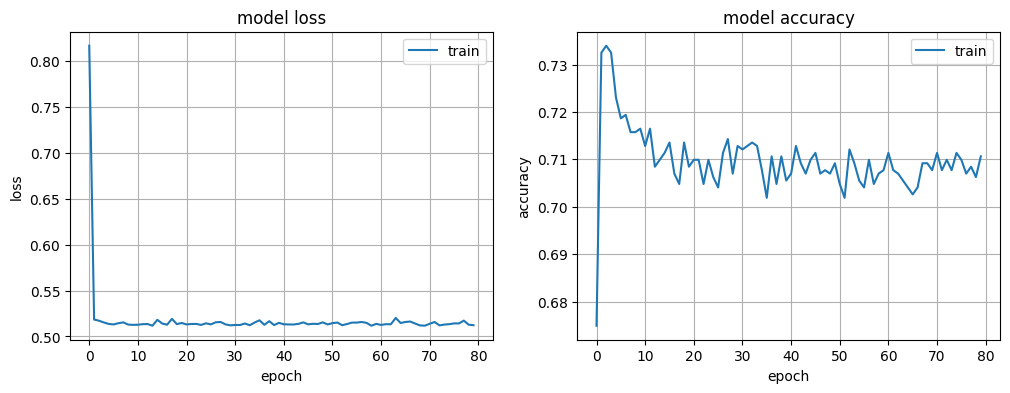

In [40]:
# plot the development of the accuracy and the loss during the training
fig, axs = plt.subplots(1,2, figsize=(12,4))
ax = axs[0]
ax.plot(history.history['loss'], label="loss")
ax.set_title('model loss')
ax.set_ylabel('loss')
ax.set_xlabel('epoch')
ax.legend(['train'])
ax.grid()

ax = axs[1]
ax.plot(history.history['accuracy'], label="accuracy")
ax.set_title('model accuracy')
ax.set_ylabel('accuracy')
ax.set_xlabel('epoch')
ax.legend(['train'])
ax.grid()

### ✏️ **YOUR TASK:**

What do you make of the two plots above? How did the weight-tuning process work in terms of loss and performance?

Did the model get better with progressing training cycles?


<details>
  <summary>🔑 Click here to View Answers:</summary>



- The simple, single neuron network seems to have converged to its solution after the first epoch.
- This is due to the fact that we are dealing with a trivial network setup, where the loss landscape is convex and low-dimensional.

</details>



### Plotting the learned decision boundary
Let's visualize which decision boundary was learned by the fcNN with only one output neuron (and no hidden layer).  
As you can see the decision boundary is a straight line. This is not a coincidence but a general property of a single artificial neuron with a sigmoid as activation function and no hidden layer, also known as logistic regression.


82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


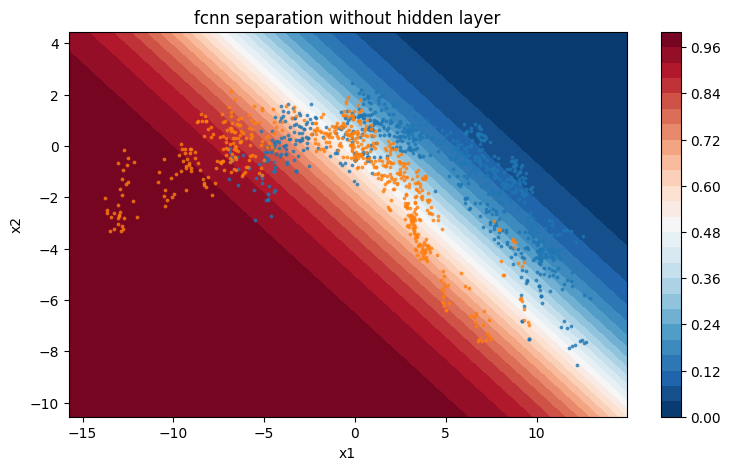

In [41]:
plotModel(X, Y, model_neuron, 'fcnn separation without hidden layer')

## fcNN with one hidden layer

We know that the boundary between the two classes is not descriped very good by a line. Therefore a single neuron is not appropriate to model the probability for a fake banknote based on its two features. To get a more flexible model, we introduce an additional layer between input layer and output layer. This is called hidden layer. Here we use a hidden layer with 8 neurons. We also change the ouputnodes form 1 to 2, to get two ouputs for the probability of real and fake banknote. Because we now have 2 outputs, we use the *softmax* activation function in the output layer. The softmax activation ensures that the output can be interpreted as a probability (see, e.g., [here](https://www.brandonrohrer.com/softmax) for more details).

### Definition of the network with one hidden layers                                                                                                                     

In [49]:
# Definition of the network
input = keras.Input(shape=(2,))
x = Dense(8, activation="relu")(input)
output = Dense(2, activation="softmax")(x)

model_hidden = keras.Model(input, output)


In [50]:
sgd = keras.optimizers.SGD(learning_rate = 0.15)
model_hidden.compile(loss='categorical_crossentropy',
              optimizer=sgd,
              metrics=['accuracy'])

In this output summary we see that we now have a lot more trainable parameters than before.

| Parameters | Formula | Calculation |
|------------|---------|-------------|
| 24 | inputdim · outputdim + outputbias | 2 · 8 + 8 |
| 18 | inputdim · outputdim + outputbias | 8 · 2 + 2 |

In [51]:
model_hidden.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42 (168.00 B)

 Trainable params: 42 (168.00 B)

 Non-trainable params: 0 (0.00 B)

In [52]:
from keras.utils import to_categorical
# Transforms Y=0 to (1,0) and Y=1 to (0,1)
Y_c=to_categorical(Y,2)
Y[0:5], Y_c[0:5]

(array([0., 0., 0., 0., 0.]),
 array([[1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.]]))

In the next cell, train the network. In other words, we tune the parameters that were initialized randomly with stochastic gradient descent to minimize our loss function (the categorical crossentropy). We set the batchsize to 128 per updatestep and train for 400 epochs.

In [53]:
# Training of the network
start_time = time.time()
history = model_hidden.fit(X, Y_c,
          epochs=100,
          batch_size=128,
          verbose=1)
training_time = time.time() - start_time
print(f"Torch Training Time: {training_time:.2f} seconds")


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.6545 - loss: 0.7124
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7493 - loss: 0.4626
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7580 - loss: 0.4392
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7617 - loss: 0.4360
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7668 - loss: 0.4287
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7690 - loss: 0.4215
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7806 - loss: 0.4140
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7777 - loss: 0.4088
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7857 - loss: 0.4112
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7806 - loss: 0.4076
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7864 - loss: 0.3984  
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accura

In [54]:
print(f"Torch Training Time: {training_time:.2f} seconds")

Torch Training Time: 4.18 seconds


### Learning curve

Let's elaborate on that idea of a **learning curve**. What does it show?

After each epoch (i.e. after all data items have been used once for gradient descent), the average loss during the iterations of that epoch are computed and stored (same for the performance metric, here `accuracy`). These two values, plotted against epoch number, are part of a learning curve. The learning curve can be extended with more information and statistics, we'll get to that later.

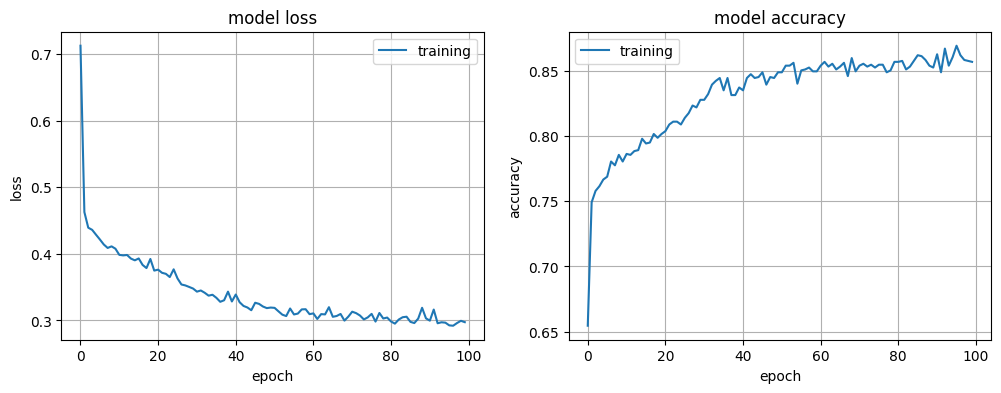

In [55]:
fig = plot_learning_curves(history);

#### 👆 **COMPARE**

You can see that after 100 epochs, we predict around 87% of our data correctly and have a loss of around 0.29 (these values can vary from run to run). How does that compare to the single neuron network?

### Plotting the learned decision boundary
Let's visualize which decision boundary was learned by the fcNN with the hidden layer
As you can see the decision boundary is a now curved and not straight anymore. The model (with the hidden layer in the middle) separates the the two classes in the training data better and is able to learn non-linear decision boundaries.



82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


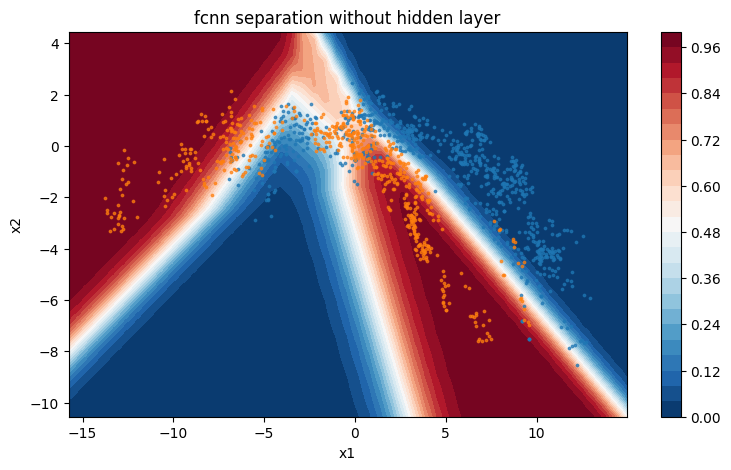

In [56]:
plotModel(X, Y, model_hidden, 'fcnn separation without hidden layer')

## 🔧 **YOUR TASK:**

- Add more hidden layers and play around with the training epochs
- What do you observe? Look at the learned decision boundary. How does the loss and the accuracy change?



In [ ]:
## YOUR CODE HERE ##

### 🔑 **Solution:**

<details>
  <summary>🔑 Click here to View Answers:</summary>



- Accuracy increases a bit to ~ 0.91 , the loss (NLL) is around 0.20  with this model
- faster convergence
- Decision boundaries do not vary that much

</details>


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.6662 - loss: 0.6413
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7216 - loss: 0.5492
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7413 - loss: 0.4816
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7631 - loss: 0.4361
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7733 - loss: 0.4115
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7857 - loss: 0.3921
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7945 - loss: 0.3721
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8134 - loss: 0.3570
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8258 - loss: 0.3396
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8397 - loss: 0.3261
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8542 - loss: 0.3141 
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accura

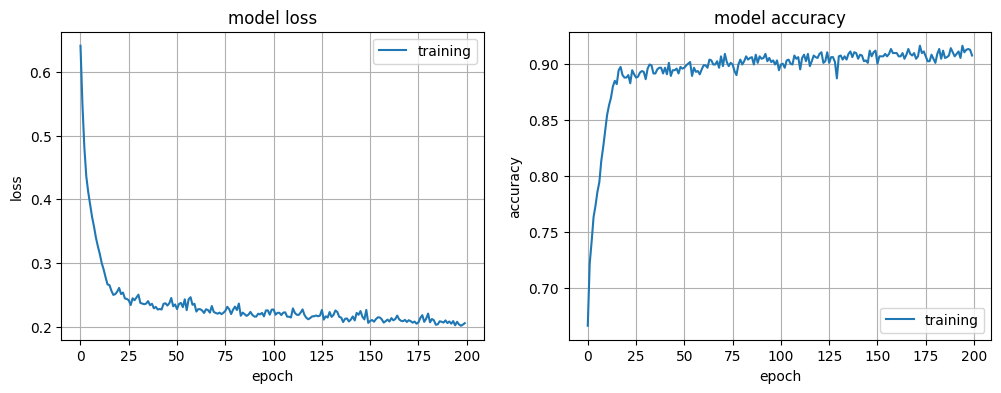

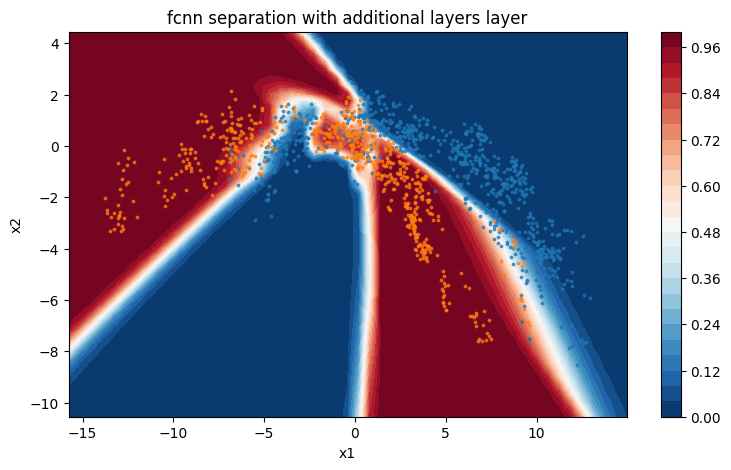

In [57]:
# @title Possible Network { display-mode: "form" }

import keras
from keras.layers import Dense

# Definition of the network using Functional API
inputs = keras.Input(shape=(2,))
x = Dense(128, activation='relu')(inputs)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)
x = Dense(8, activation='relu')(x)
# Softmax gets the probability for each class
# Note that for 2-class classification we could have also used a single output
# with sidmoid activation function
output = Dense(2, activation='softmax')(x)

model = keras.Model(inputs=inputs, outputs=output)

# compile to graph
model.compile(loss='categorical_crossentropy',
              optimizer='adam',                  # Adam optimizer
              metrics=['accuracy'])

# Training of the network
history = model.fit(X, Y_c,
          epochs=200,
          batch_size=128,
          verbose=1)

# plot the development of the accuracy and loss during the training
plot_learning_curves(history);

plotModel(X,Y,model, 'fcnn separation with additional layers layer')


In [ ]:
# Alterantively, you can also define in the network using the so called
# "sequential style"
model_seq_style = keras.Sequential([
    Dense(128, activation='relu', input_shape=(2,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(2, activation='softmax')
])

## Effect of the Mini-Batch size



In [64]:
reset_weights(model_hidden)

In [65]:
batch_size = 32
print(f"The training data has {X.shape[0]} items.")
print(f"With a batch size of {batch_size} there will be {np.ceil(X.shape[0]/batch_size)} iterations per epoch.")

The training data has 1372 items.
With a batch size of 32 there will be 43.0 iterations per epoch.


In [66]:
# We will train the network with one hidden layer using an adjustable batch size.
start_time = time.time()
history = model_hidden.fit(X, Y_c,
          epochs=100,
          batch_size=batch_size,
          verbose=1)
training_time = time.time() - start_time
print(f"Training run-time: {training_time:.2f} seconds")


Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7136 - loss: 0.5243
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step - accuracy: 0.7653 - loss: 0.4487
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7784 - loss: 0.4240
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7799 - loss: 0.4156
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7923 - loss: 0.3933
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7952 - loss: 0.3853
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 943us/step - accuracy: 0.7988 - loss: 0.3851
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - accuracy: 0.8054 - loss: 0.3820
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step - accuracy: 0.8207 - loss: 0.3647
Epoch 10/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 923us/step - accuracy: 0.8302 - loss: 0.3667
Epoch 11/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step - accuracy: 0.8236 - loss: 0.3519
Epoch 12/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

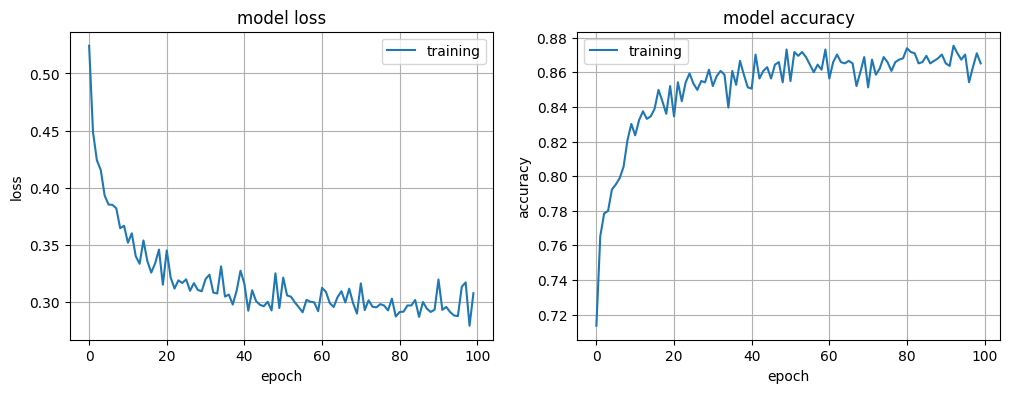

In [67]:
plot_learning_curves(history);

Note how the learning curves are much "noiser", i.e. less smooth. This is because each gradient update has less data it is based on (the mini-batch size) and gradients are there fore subject to more stochstic fluctuation, which again is imparted on the fluctuations in the loss that is achieved after the gradient update step.

## 🔧 **YOUR TASK:**

- Testrun different batch sizes, such as 32, 64, 128, 256. What do you observe in the learning curves? Make sure to always reset the weights of the network before you try a new batch size (`reset_weights(model_hidden)`).
- Try using a batch size that is identical to the number of training items in `X`. How does the training curve look like?
- Can you explain the different characteristics of the learning curves that occur for different batch sizes?



In [ ]:
## YOUR CODE HERE ##

### 🔑 **Solution:**

Text(0.5, 0.98, 'Learning curves with batch size 1372')

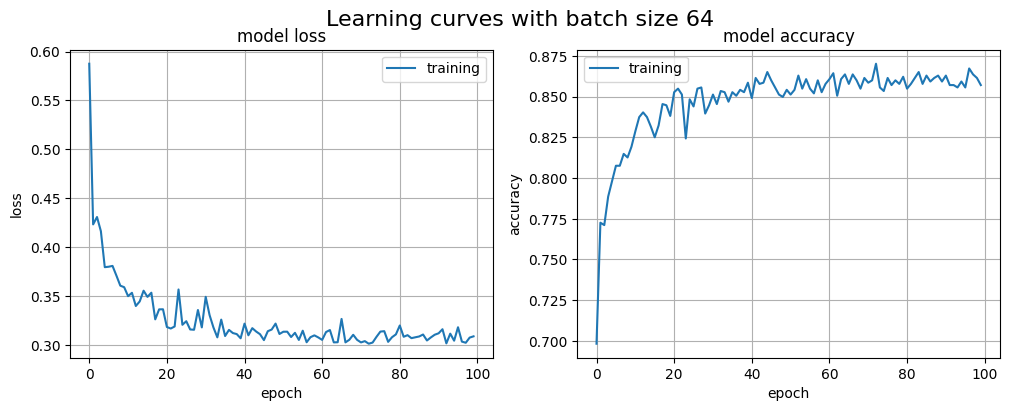

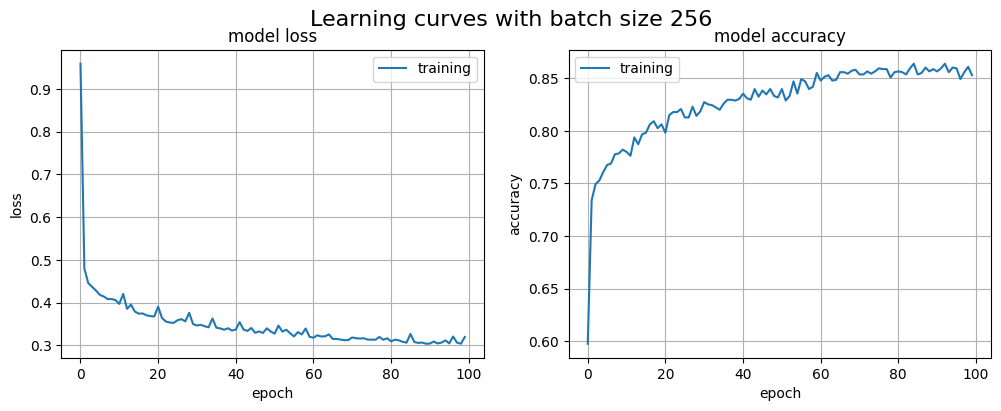

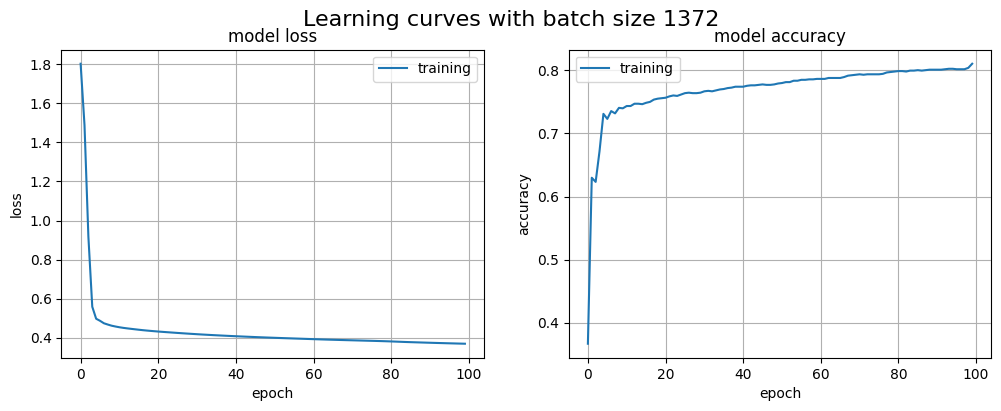

In [23]:
# @title Answer { display-mode: "form" }

reset_weights(model_hidden)
batch_size = 64
history = model_hidden.fit(X, Y_c,
          epochs=100,
          batch_size=batch_size,
          verbose=0)

fig = plot_learning_curves(history)
fig.suptitle(f'Learning curves with batch size {batch_size}', fontsize=16)


reset_weights(model_hidden)
batch_size = 256
history = model_hidden.fit(X, Y_c,
          epochs=100,
          batch_size=batch_size,
          verbose=0)

fig = plot_learning_curves(history)
fig.suptitle(f'Learning curves with batch size {batch_size}', fontsize=16)


reset_weights(model_hidden)
batch_size = X.shape[0]  # full batch
history = model_hidden.fit(X, Y_c,
          epochs=100,
          batch_size=batch_size,
          verbose=0)

fig = plot_learning_curves(history);
fig.suptitle(f'Learning curves with batch size {batch_size}', fontsize=16)

<details>
  <summary>🔑 Click here to View Answers:</summary>



- The learning curve becomes smoother with increasing batch size.
- The lowest training loss and best training performance (measured as accuracy) is not reached by the largest batch size.
- Small batch sizes have more "stochasticity" because the stochasticity of the mini-batch selection and the small-number statistics.
- Because of this stochasticity the smaller batch training procedures can escape local minima and often perform better than using a too large batch size.
- Too much stochasticity will prevent the optimizer from converging quickly enough, though. This is a **trade-off situation**.

</details>


Some remarks regarding mini-batch size, stochasticity and learning rates:

If you increase your batch size by a factor of `k` (e.g., from 32 to 256, i.e. `k=8`), you are performing `k` times fewer updates per epoch (can you explain why?). To maintain a similar learning speed and ensure the model doesn't take forever to converge, you generally need to scale your learning rate accordingly. Here's a rule of thumb:

$\eta_\texttt{new}$ = $\eta_\texttt{old} \cdot k$

or

$\eta_\texttt{new}$ = $\eta_\texttt{old} \cdot \sqrt{k}$


*Careful:* The "noise" of small batches helps the model avoid narrow, sharp valleys in the loss landscape that don't hold up well on test data.


## Validation metrics

We will now evaluate the performance of our model on a held-out validation set. This is important to see how well our model generalizes to unseen data.
We first split the data into a training set and a validation set. We use 80% of the data for training and 20% for validation.

In [ ]:
# Randomly split data into training and validation sets, w/o sklearn

# Randomly select a 20% set of the data indices for validation
val_idx = np.random.choice(X.shape[0], size=int(0.2*X.shape[0]), replace=False)
# Create a selection mask for training
train_mask = np.ones(X.shape[0], dtype=np.bool)
train_mask[val_idx] = 0
# Split the data into training and validation
X_train = X[train_mask, :]
y_train = Y_c[train_mask, :]
X_val = X[~train_mask, :]
y_val = Y_c[~train_mask, :]


In [ ]:
reset_weights(model_hidden)

# Training of the network
start_time = time.time()
history = model_hidden.fit(X_train, y_train,
          epochs=600,
          batch_size=128,
          validation_data=(X_val, y_val),
          verbose=0)
training_time = time.time() - start_time
print(f"Training run-time: {training_time:.2f} seconds")


In [ ]:
plot_learning_curves(history);

print(f"Final validation accuracy: {np.mean(history.history["val_accuracy"][-4:-1]):.04f}")
print(f"Final accuracy: {np.mean(history.history["accuracy"][-4:-1]):.04f}")

In [ ]:
reset_weights(model_hidden)

# Training of the network
start_time = time.time()
history = model_hidden.fit(X_train, y_train,
          epochs=600,
          batch_size=1098,
          validation_data=(X_val, y_val),
          verbose=0)
training_time = time.time() - start_time
print(f"Training run-time: {training_time:.2f} seconds")


In [ ]:
fig = plot_learning_curves(history);
print(f"Final validation accuracy: {np.mean(history.history["val_accuracy"][-4:-1]):.04f}")
print(f"Final accuracy: {np.mean(history.history["accuracy"][-4:-1]):.04f}")

In [ ]:
plotModel(X,Y,model_hidden, 'fcnn separation with additional layers layer')

In [ ]:
fig = plot_learning_curves(history);
fig.suptitle(f'Learning curves with batch size {batch_size}', fontsize=16)

## Diagnose our network (optional)


Let's consider the above network with 1 hidden layer that consists of 8 neurons. We've discussed in class that we can think of this network as transforming our input data into 8 different new "perspectives" on the data. Those 8 "new features" are then effectively the input to a logistic regression that combines them into an estimate of the probability that the bank notes are fake.

### Input space as seen through the 8 hidden neurons

That combination of the 8 features in our final layer (that single, last neuron) allows a non-linear response because the outputs went through a non-linear activation function (with `ReLU`, the negative parts are cropped, that's a nonlinear transformation). Therefore, let's have a look at how those 8 "feature mappings" look like, i.e. how do the features map over our `x1, x2` input space.

In [ ]:
model_ = model_hidden
model_.summary()

In [ ]:
# Create a grid over the input space (x1, x2)
x1list = np.linspace(-4, 4, 50) # Define 100 points on the w1-axis
x2list = np.linspace(-4, 4, 50) # Define 100 points on the w2-axis
X1, X2 = np.meshgrid(x1list, x2list)

# Convert the mesh-like array shapes into a dataframe shape (n x 2)
X_grid = np.r_[
    X1.reshape(1, 50*50),
    X2.reshape(1, 50*50)
].T

In [ ]:
# Create a sub-model, whose output is some intermediate layer of the full model
intermediate_layer_model = keras.Model(
    inputs=model_.input,
    outputs=model_.layers[1].output
)

# Pass the grid of inputs through that model and visualize the result
l1_grid = intermediate_layer_model.predict(X_grid)

In [ ]:
n_neurons = l1_grid.shape[1]
ncols = 4
fig, axs = plt.subplots(figsize=(8,4), nrows=n_neurons//ncols, ncols=ncols)
plt.subplots_adjust(wspace=0, hspace=0)

levels = np.linspace(l1_grid.min(), l1_grid.max(), 50)

for i in range(n_neurons):
    l1_grid_sel = l1_grid[:,i].reshape(X1.shape)
    ax = axs.flat[i]
    # levels = np.linspace(0, 20, num=101)
    cp = ax.contourf(X1, X2, l1_grid_sel, levels=levels, cmap='viridis')
    #h, = ax.plot(w1_sol, w2_sol, nll_sol, "rx", zorder=99)
    #ax.legend([h], ["Best solution"])
    # cbar = fig.colorbar(cp)
    # ax.set_xlabel('x1')
    # ax.set_ylabel('x2')
    ax.text(0.95, 0.95, i, transform=ax.transAxes, color='white', ha='right', va='top',
        bbox=dict(facecolor='white', alpha=0.0, edgecolor='none'))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(False)

fig.colorbar(cp, ax=axs.ravel().tolist(), orientation='vertical', label='Neuron activation')
fig.suptitle('Activations of first hidden layer neurons over input space', fontsize=16)


In [ ]:
# Get the weights of the last layer in `model_`
model_weights = model_.get_weights()
last_layer_weights = model_weights[-2]
last_layer_bias = model_weights[-1]

# List the weights by which the panels above will be weighted to create the activation of the 0-th
# output neuron (corresponding to a label of `0`). Higher values of that activation will lead to
# higher predicted probability for that target value.
# Can you see what these weights will do with the response panels shown right above?
last_layer_weights[:,0]

<details>
  <summary>🔑 Click here to View Answers:</summary>



- The final layer can be thought of additively mixing the shapes seen in the activation maps.
- For instance, neuron `7` in the hidden layer give areas in the upper right a higher value whereas neuron `5` increases values at the bottom of the inputs space.
- The values in `last_layer_weights[:,0]` tell us with what coefficients these "maps" are mixed in together for the first of two output neurons (the one that stands for `0`, i.e. "real bank note"). The cumulated activation "maps" are compared to the corresponding cumulated activation maps of the other output neuron (with coefficients `last_layer_weights[:,1]`. That comparison is done with `softmax` which ensures they sum to one.
- We see that the 7th value for the 0-th neuron (`last_layer_weights[7,0]`) has a high positive value. This will lead to an increase in output value for the 0-th output neuron on the upper right part of the inputs space.

</details>


### (Optional) Relationship between the 8 neurons

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(l1_grid.T, method='ward')

# 3. Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=[f"{i}" for i in range(len(l1_grid.T))])

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Neuron ID')
plt.ylabel('Distance (Ward)')

In [ ]:
Cmat = np.corrcoef(l1_grid.T)

fig, ax = plt.subplots()
img = ax.imshow(Cmat, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(img, label='Correlation Coefficient')
ax.set_title('Correlation Matrix Heatmap')
ax.set_xlabel("Neuron ID")
plt.xticks(range(len(Cmat)), labels=[f'{i}' for i in range(len(Cmat))]);
#plt.yticks(range(len(Cmat)), labels=[f'Var {i}' for i in range(len(Cmat))]);